## Chargement des packages

In [1]:

# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
#from pandas_profiling import ProfileReport


## Base des données


 les données sont disponibles sur Kaggle  https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset?resource=download


 ### objectif de l'analyse

L'objectif de cette analyse est de construire un modèle de classification pour prédire si une personne est eligible pour un prêt en fonction de ses caractéristiques. Cette base de données sera divisée en ensembles d'apprentissage et de test pour entraîner et évaluer les performances du modèle.  

### Contenu de la base de données

La base de données contient les colonnes suivantes :
 - `Loan_ID` : identifiant du prêt
 - `Gender` : sexe de l'emprunteur
- `Married` : statut marital de l'emprunteur
- `Dependents` : nombre de personnes à charge
 - `Education` : niveau d'éducation de l'emprunteur
 - `Self_Employed` : statut d'emploi indépendant de l'emprunteur
 - `ApplicantIncome` : revenu de l'emprunteur
 - `CoapplicantIncome` : revenu du co-emprunteur
 - `LoanAmount` : montant du prêt demandé
 - `Loan_Amount_Term` : durée du prêt en mois
 - `Credit_History` : historique de crédit de l'emprunteur (0 = mauvais, 1 = bon)
 - `Property_Area` : zone géographique de la propriété 
 - `Loan_Status` : statut du prêt (Y = approuvé, N = non approuvé)

 ### Objectif de l'analyse
 L'objectif de cette analyse est de construire un modèle de classification pour prédire si une personne est éligible pour un prêt en fonction de ses caractéristiques. Cette base de données sera divisée en ensembles d'apprentissage et de test pour entraîner et évaluer les performances du modèle.    


## Importation et nettoyage des données

In [2]:
data_path = Path(r"C:\Users\nmako\OneDrive\Documents\Data-Science-Projects-Repository\Machine Learning TP\Application-ML-Detection-Defauts-Paiements-Credits-Bancaires\data\raw\train_credit.csv")
data = pd.read_csv(data_path)
df = data.copy()
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.isna().sum()  # Vérification des valeurs manquantes
#import missingno as msno

#plt.figure(figsize=(4, 3))
#msno.bar(df)  # Visualisation des valeurs manquantes

df.isna().sum().sort_values(ascending=False)


Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Loan_ID               0
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
# remplacement des valeurs manquantes

cat_data = df.select_dtypes(include=['object']).columns
num_data = df.select_dtypes(exclude=['object']).columns

cat_data = df[cat_data].apply(lambda x: x.fillna(x.mode()[0])) # remplacement des valeurs manquantes dans les colonnes catégorielles par la valeur la plus fréquente
num_data = df[num_data].fillna(method = 'bfill') # remplacement des valeurs manquantes dans les colonnes numériques par la valeur précédente

#concatenation des deux dataframes
df = pd.concat([cat_data, num_data], axis=1)

In [5]:
df.isna().sum()  # Vérification des valeurs manquantes restantes

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Property_Area        0
Loan_Status          0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

In [6]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,LP001002,Male,No,0,Graduate,No,Urban,Y,5849,0.0,128.0,360.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,Rural,N,4583,1508.0,128.0,360.0,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y,3000,0.0,66.0,360.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y,2583,2358.0,120.0,360.0,1.0
4,LP001008,Male,No,0,Graduate,No,Urban,Y,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y,2900,0.0,71.0,360.0,1.0
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y,4106,0.0,40.0,180.0,1.0
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y,8072,240.0,253.0,360.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y,7583,0.0,187.0,360.0,1.0


## Analyses Explo

l analyse exploratoire des données consiste à explorer les données pour en extraire des informations utiles, identifier des tendances, des relations entre les variables,
et des anomalies, et de mieux comprendre les données avant de les utiliser pour l'apprentissage automatique.

Tools : Sweetviz and pandas-profiling

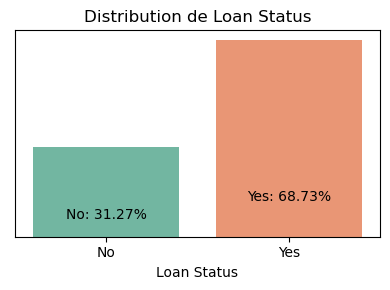

In [8]:
# analyse de la varible cible
target = df['Loan_Status'].apply(lambda x: 1 if x == 'Y' else 0)
plt.figure(figsize=(4, 3))
sns.countplot(x=target, palette='Set2')
plt.title('Distribution de Loan Status')
plt.xlabel('Loan Status')
yes = target.value_counts()[1] / len(target) * 100
no = target.value_counts()[0] / len(target) * 100
plt.text(1, yes + 1, f'Yes: {yes:.2f}%', ha='center', va='bottom')
plt.text(0, no + 1, f'No: {no:.2f}%', ha='center', va='bottom')
plt.xticks([1, 0], ['Yes', 'No'])
#remove the y-axis label
plt.ylabel('')
# remove the y-axis ticks
plt.yticks([])
plt.tight_layout()
plt.show()

c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\seaborn\axisgrid.py:712: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 800x600 with 0 Axes>

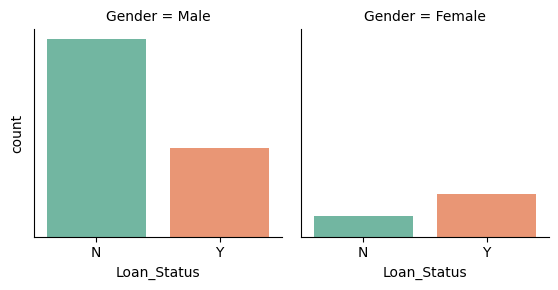

In [9]:
# analyse de la relation entre variable cible et le gender
plt.figure(figsize=(8, 6))
grid = sns.FacetGrid(df, col='Gender', height=3, aspect=1)
grid.map(sns.countplot, 'Loan_Status', palette='Set2')
plt.yticks([]) 
plt.show()

c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\seaborn\axisgrid.py:712: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 800x600 with 0 Axes>

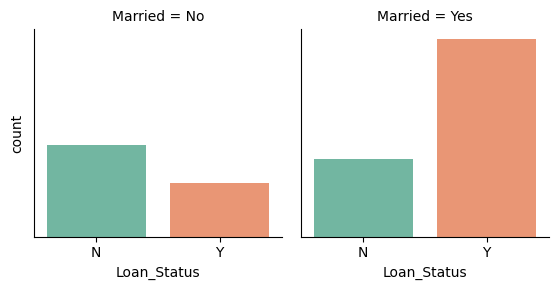

In [10]:
# analyse de la relation entre variable cible et le gender
plt.figure(figsize=(8, 6))
grid = sns.FacetGrid(df, col='Married', height=3, aspect=1)
grid.map(sns.countplot, 'Loan_Status', palette='Set2')
plt.yticks([]) 
plt.show()

In [11]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,LP001002,Male,No,0,Graduate,No,Urban,Y,5849,0.0,128.0,360.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,Rural,N,4583,1508.0,128.0,360.0,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y,3000,0.0,66.0,360.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y,2583,2358.0,120.0,360.0,1.0
4,LP001008,Male,No,0,Graduate,No,Urban,Y,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y,2900,0.0,71.0,360.0,1.0
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y,4106,0.0,40.0,180.0,1.0
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y,8072,240.0,253.0,360.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y,7583,0.0,187.0,360.0,1.0


## Modelisation avec Random Forest

In [12]:
#les features et la cible
features = df.drop(['Loan_Status','Loan_ID'], axis=1)
target = df['Loan_Status'].apply(lambda x: 1 if x == 'Y' else 0)  # Conversion de la variable cible en binaire

In [13]:
# traitement des données feature

features_cat = features.select_dtypes(include=['object']).columns
features_num = features.select_dtypes(exclude=['object']).columns

In [14]:
# remplacer les valeurs features catégorielles par des valeurs numériques avec one hot encoding, et standardiser les features numériques

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(drop='first'), features_cat)
    ])


In [15]:
# mise en plce du pipeline complet
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators = 100, random_state=42))
])

In [16]:
# separation des donnees de test et d'entrainement
from sklearn.model_selection import train_test_split
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [17]:
# Entrainement du modèle
pipeline.fit(features_train, target_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
#fonction d'évaluation du modèle
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def model_evaluation(pipeline, features, target, labels=[" Eligible ", "Non Eligible "]):
    y_pred = pipeline.predict(features)
    y_proba = pipeline.predict_proba(features)[:, 1]

    # Matrice de confusion
    cm = confusion_matrix(target, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels)
    plt.title("Matrice de confusion")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    # Rapport global
    print("Rapport de classification :\n")
    print(classification_report(target, y_pred, target_names=labels))


    # Retourner un dictionnaire des scores
      # Retourner un dictionnaire des scores
    return {
        "accuracy": accuracy_score(target, y_pred),
        "precision": precision_score(target, y_pred),
        "recall": recall_score(target, y_pred),
        "f1_score": f1_score(target, y_pred)
    }



In [ ]:
#model_evaluation(pipeline, features_test, target_test)

In [21]:
#enregistrement du Pipeline de modèle
joblib.dump(pipeline, '../models/rf_credit_model.pkl')


['../models/rf_credit_model.pkl']

In [22]:
#chargement du modèle
loaded_model = joblib.load('../models/rf_credit_model.pkl')

In [23]:
#utilisation du modèle chargé pour faire des prédictions
predictions = loaded_model.predict(features_test)

In [24]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,LP001002,Male,No,0,Graduate,No,Urban,Y,5849,0.0,128.0,360.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,Rural,N,4583,1508.0,128.0,360.0,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y,3000,0.0,66.0,360.0,1.0
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y,2583,2358.0,120.0,360.0,1.0
4,LP001008,Male,No,0,Graduate,No,Urban,Y,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y,2900,0.0,71.0,360.0,1.0
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y,4106,0.0,40.0,180.0,1.0
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y,8072,240.0,253.0,360.0,1.0
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y,7583,0.0,187.0,360.0,1.0
